In [64]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [66]:
train_df = pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/digit-recognizer/test.csv")

In [67]:
train_df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [68]:
train_df.shape

(42000, 785)

In [69]:
test_df.shape

(28000, 784)

In [70]:
x = train_df.drop('label' , axis = 1)
y = train_df['label']

In [71]:
image = x.iloc[0].values

In [72]:
image = image.reshape(28,28)

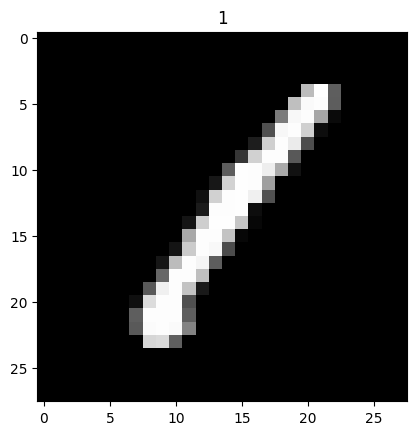

In [73]:
plt.imshow(image , cmap = 'gray')
plt.title(y.iloc[0])
plt.show()

In [74]:
x = x/255.0
test_df = test_df/255.0

In [75]:
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [76]:
x_train = x_train.values.reshape(-1,28,28,1)
x_val = x_val.values.reshape(-1,28,28,1)
test_df = test_df.values.reshape(-1,28,28,1)

In [77]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout

In [78]:
model = Sequential([
    Conv2D(32, (3,3), activation = 'relu', input_shape = (28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation = 'relu', input_shape = (28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation = 'relu'),
    Dropout(0.5),
    Dense(10, activation = 'softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [79]:
model.compile( optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [80]:
history = model.fit(
    x_train, y_train, validation_data = (x_val, y_val), epochs = 10
)

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.9105 - loss: 0.2891 - val_accuracy: 0.9761 - val_loss: 0.0722
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.9693 - loss: 0.1010 - val_accuracy: 0.9815 - val_loss: 0.0565
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.9780 - loss: 0.0766 - val_accuracy: 0.9864 - val_loss: 0.0431
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.9804 - loss: 0.0630 - val_accuracy: 0.9869 - val_loss: 0.0428
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.9843 - loss: 0.0526 - val_accuracy: 0.9880 - val_loss: 0.0362
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9869 - loss: 0.0436 - val_accuracy: 0.9875 - val_loss: 0.0384
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.9873 - loss: 0.0390 - val_accuracy: 0.9879 - val_loss: 0.0337
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9886 -

In [81]:
model.evaluate(x_val, y_val)

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9888 - loss: 0.0465


[0.046511102467775345, 0.9888095259666443]

In [82]:
predictions = model.predict(test_df)

875/875 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


In [83]:
predictions = np.argmax(predictions, axis = 1)

In [84]:
submission = pd.DataFrame({
    'ImageId' : range(1, len(predictions)+1),
    'Label' : predictions
})

In [85]:
submission.to_csv('submission_2.csv', index = False)

In [86]:
model.save("digit_recognizer_cnn.h5")